# UK Labour Promise Tracker — Group Analysis Notebook

**Course:** Data-Driven Research & Digital Humanities Lab  
**Project:** UK Labour Housing Promise Tracker  
**Research question:** *To what extent can UK Labour’s 2024 manifesto promises on housing be tracked through parliamentary, governmental, budgetary, statistical, and web-dashboard evidence?*
**Promise Tracker Website:** https://uk-labour-promise-tracker-muclrffhxxvvljjzezpvym.streamlit.app/

This notebook is the technical companion to our report. It explains our data, methods, code, results, visualisations, website pipeline, and limitations.

---

## Group division

| Task | Member | Main responsibility |
|---|---|---|
| T1 | Selin | Project overview, research question, and final integration |
| T2 | Simone | Background, related work, and references |
| T3 | Grace | Promise dataset and manual review logic |
| T4 | Alessia | Automatic evidence collection and update pipeline |
| T5 | Tia | Analysis, results, and visualisations |
| T6 | Shenru | Website dashboard, user guide, discussion, and limitations |

**Important editing rule:** each person should mainly edit their own section, but the final integration should be checked together.


# 0. Notebook guide

This notebook is organised according to the six-person division above.

The code is written so that the notebook can still run even if some files are missing or if the folder structure is slightly different.  
The main expected folders are:

```text
UK-LABOUR-PROMISE-TRACKER/
├── data/
│   └── processed/
│       ├── outcome_evidence.csv
│       ├── parliament_bills_raw.csv
│       ├── parliamentary_evidence.csv
│       └── promise_parliamentary_summary.csv
├── notebooks/
│   ├── 01_promise_dataset.csv
│   ├── 02_comparison_table.csv
│   ├── 03_background_info_and_introduction.ipynb
│   ├── 04_parliamentary_legal_evidence.ipynb
│   └── 05_government_budget_statistics_evidence.ipynb
├── notes/
│   ├── task2_related_work.md
│   ├── task5_sources_notes.md
│   └── task6_validation_reflection.md
└── promise-tracker-website/
    ├── data/
    │   └── data/
    │       └── progress_timeline.csv
    ├── evidence_reviewed.csv
    ├── evidence.csv
    ├── progress_timeline.csv
    ├── promise_progress_timeline.csv
    ├── promise_status_suggestions.csv
    └── promises.csv
```

If your folder structure is different, only update the path list in Section 1.


# 1. Setup, imports, and file paths

This section imports the libraries and creates helper functions for loading files safely.


In [1]:
# Basic analysis
import pandas as pd
import numpy as np
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

# ------------------------------------------------------------
# Robust project-root detection
# ------------------------------------------------------------
# This solves the common problem where VS Code runs the notebook
# from the notebooks/ folder instead of the project root folder.
#
# Expected project root contains at least one of:
# - data/processed
# - promise-tracker-website
# - notes
# - notebooks

def detect_project_root(start_path=None):
    """
    Detect the UK-LABOUR-PROMISE-TRACKER project root by walking upward
    from the current working directory.
    """
    if start_path is None:
        start_path = Path.cwd()
    start_path = Path(start_path).resolve()

    candidates = [start_path] + list(start_path.parents)

    for candidate in candidates:
        has_data = (candidate / "data" / "processed").exists()
        has_website = (candidate / "promise-tracker-website").exists()
        has_notebooks = (candidate / "notebooks").exists()
        has_notes = (candidate / "notes").exists()

        if has_data or has_website or (has_notebooks and has_notes):
            return candidate

    # fallback: use current folder
    return start_path


PROJECT_ROOT = detect_project_root()

# Main folders
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
NOTES_DIR = PROJECT_ROOT / "notes"
WEBSITE_DIR = PROJECT_ROOT / "promise-tracker-website"
WEBSITE_DATA_DIR = WEBSITE_DIR / "data"
WEBSITE_NESTED_DATA_DIR = WEBSITE_DIR / "data" / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook setup complete.")
print("Detected project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd().resolve())
print("Data processed folder:", DATA_PROCESSED, "| exists:", DATA_PROCESSED.exists())
print("Notebooks folder:", NOTEBOOKS_DIR, "| exists:", NOTEBOOKS_DIR.exists())
print("Website folder:", WEBSITE_DIR, "| exists:", WEBSITE_DIR.exists())

Notebook setup complete.
Detected project root: C:\Users\darko\data-driven\uk-labour-promise-tracker
Current working directory: C:\Users\darko\data-driven\uk-labour-promise-tracker\notebooks
Data processed folder: C:\Users\darko\data-driven\uk-labour-promise-tracker\data\processed | exists: True
Notebooks folder: C:\Users\darko\data-driven\uk-labour-promise-tracker\notebooks | exists: True
Website folder: C:\Users\darko\data-driven\uk-labour-promise-tracker\promise-tracker-website | exists: True


In [2]:
def find_existing_file(candidate_paths, filename=None):
    """
    Return the first existing file from a list of possible paths.
    If none exists, search the whole project folder for the filename.
    """
    for path in candidate_paths:
        path = Path(path)
        if path.exists():
            return path

    # Fallback: recursive project search by filename
    if filename:
        matches = list(PROJECT_ROOT.rglob(filename))
        # Avoid hidden/system folders if possible
        matches = [m for m in matches if ".git" not in str(m)]
        if matches:
            # Prefer shorter paths because they are usually closer to the intended file
            matches = sorted(matches, key=lambda p: len(str(p)))
            return matches[0]

    return Path(candidate_paths[0])


def load_csv_safely(name, candidate_paths):
    """
    Load a CSV from possible paths.
    Returns an empty DataFrame if the file is not found.
    This function will not stop the notebook if one file is missing.
    """
    path = find_existing_file(candidate_paths, filename=name)
    if path.exists():
        try:
            df = pd.read_csv(path)
            print(f"✅ Loaded {name}: {path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path} | shape={df.shape}")
            return df
        except Exception as e:
            print(f"⚠️ Found {name}, but could not load it: {path}")
            print("Error:", e)
            return pd.DataFrame()
    else:
        print(f"⚠️ Missing {name}. The notebook will continue without this file.")
        print("   Tried paths:")
        for p in candidate_paths:
            print("   -", p)
        return pd.DataFrame()


def clean_column_names(df):
    """
    Make column names easier to use in Python.
    """
    if df.empty:
        return df
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df


def preview_df(df, name, rows=5):
    """
    Display a simple preview and basic information.
    """
    print(f"\n{name}")
    print("-" * len(name))
    if df.empty:
        print("This dataset is empty or not loaded.")
    else:
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head(rows))


def find_column(df, possible_names):
    """
    Find the first column in df matching any possible name.
    Matching is case-insensitive after cleaning.
    """
    if df.empty:
        return None
    cleaned = {str(c).lower().strip(): c for c in df.columns}
    for name in possible_names:
        key = str(name).lower().strip()
        if key in cleaned:
            return cleaned[key]
    return None


def explain_missing_result(reason):
    """
    Print a readable message when a chart/table cannot be created yet.
    """
    print("This result cannot be created yet.")
    print("Reason:", reason)
    print("This is okay during drafting. After the correct CSV files are loaded, run this cell again.")

# 2. Load all project datasets

This section uses the actual file names from our project folder.  
It checks several possible locations because some files are in `data/processed`, some are in `notebooks`, and some are inside `promise-tracker-website`.


In [3]:
# Main analysis files
outcome_evidence = load_csv_safely("outcome_evidence.csv", [
    DATA_PROCESSED / "outcome_evidence.csv"
])

parliament_bills_raw = load_csv_safely("parliament_bills_raw.csv", [
    DATA_PROCESSED / "parliament_bills_raw.csv"
])

parliamentary_evidence = load_csv_safely("parliamentary_evidence.csv", [
    DATA_PROCESSED / "parliamentary_evidence.csv"
])

promise_parliamentary_summary = load_csv_safely("promise_parliamentary_summary.csv", [
    DATA_PROCESSED / "promise_parliamentary_summary.csv"
])

promise_dataset = load_csv_safely("01_promise_dataset.csv", [
    NOTEBOOKS_DIR / "01_promise_dataset.csv",
    DATA_PROCESSED / "01_promise_dataset.csv"
])

comparison_table = load_csv_safely("02_comparison_table.csv", [
    NOTEBOOKS_DIR / "02_comparison_table.csv",
    DATA_PROCESSED / "02_comparison_table.csv"
])

# Website/dashboard files
website_promises = load_csv_safely("promises.csv", [
    WEBSITE_DIR / "promises.csv",
    WEBSITE_DATA_DIR / "promises.csv",
    WEBSITE_NESTED_DATA_DIR / "promises.csv"
])

website_evidence = load_csv_safely("evidence.csv", [
    WEBSITE_DIR / "evidence.csv",
    WEBSITE_DATA_DIR / "evidence.csv",
    WEBSITE_NESTED_DATA_DIR / "evidence.csv"
])

evidence_reviewed = load_csv_safely("evidence_reviewed.csv", [
    WEBSITE_DIR / "evidence_reviewed.csv",
    WEBSITE_DATA_DIR / "evidence_reviewed.csv",
    WEBSITE_NESTED_DATA_DIR / "evidence_reviewed.csv"
])

progress_timeline = load_csv_safely("progress_timeline.csv", [
    WEBSITE_DIR / "progress_timeline.csv",
    WEBSITE_DATA_DIR / "progress_timeline.csv",
    WEBSITE_NESTED_DATA_DIR / "progress_timeline.csv"
])

promise_progress_timeline = load_csv_safely("promise_progress_timeline.csv", [
    WEBSITE_DIR / "promise_progress_timeline.csv",
    WEBSITE_DATA_DIR / "promise_progress_timeline.csv",
    WEBSITE_NESTED_DATA_DIR / "promise_progress_timeline.csv"
])

promise_status_suggestions = load_csv_safely("promise_status_suggestions.csv", [
    WEBSITE_DIR / "promise_status_suggestions.csv",
    WEBSITE_DATA_DIR / "promise_status_suggestions.csv",
    WEBSITE_NESTED_DATA_DIR / "promise_status_suggestions.csv"
])

# Clean column names for easier analysis
datasets = {
    "outcome_evidence": outcome_evidence,
    "parliament_bills_raw": parliament_bills_raw,
    "parliamentary_evidence": parliamentary_evidence,
    "promise_parliamentary_summary": promise_parliamentary_summary,
    "promise_dataset": promise_dataset,
    "comparison_table": comparison_table,
    "website_promises": website_promises,
    "website_evidence": website_evidence,
    "evidence_reviewed": evidence_reviewed,
    "progress_timeline": progress_timeline,
    "promise_progress_timeline": promise_progress_timeline,
    "promise_status_suggestions": promise_status_suggestions,
}

datasets = {name: clean_column_names(df) for name, df in datasets.items()}

# Reassign cleaned dataframes
outcome_evidence = datasets["outcome_evidence"]
parliament_bills_raw = datasets["parliament_bills_raw"]
parliamentary_evidence = datasets["parliamentary_evidence"]
promise_parliamentary_summary = datasets["promise_parliamentary_summary"]
promise_dataset = datasets["promise_dataset"]
comparison_table = datasets["comparison_table"]
website_promises = datasets["website_promises"]
website_evidence = datasets["website_evidence"]
evidence_reviewed = datasets["evidence_reviewed"]
progress_timeline = datasets["progress_timeline"]
promise_progress_timeline = datasets["promise_progress_timeline"]
promise_status_suggestions = datasets["promise_status_suggestions"]

✅ Loaded outcome_evidence.csv: data\processed\outcome_evidence.csv | shape=(12, 12)
✅ Loaded parliament_bills_raw.csv: data\processed\parliament_bills_raw.csv | shape=(75, 7)
✅ Loaded parliamentary_evidence.csv: data\processed\parliamentary_evidence.csv | shape=(35, 11)
✅ Loaded promise_parliamentary_summary.csv: data\processed\promise_parliamentary_summary.csv | shape=(18, 6)
✅ Loaded 01_promise_dataset.csv: notebooks\01_promise_dataset.csv | shape=(18, 7)
⚠️ Missing 02_comparison_table.csv. The notebook will continue without this file.
   Tried paths:
   - C:\Users\darko\data-driven\uk-labour-promise-tracker\notebooks\02_comparison_table.csv
   - C:\Users\darko\data-driven\uk-labour-promise-tracker\data\processed\02_comparison_table.csv
✅ Loaded promises.csv: promise-tracker-website\data\promises.csv | shape=(18, 12)
✅ Loaded evidence.csv: promise-tracker-website\data\evidence.csv | shape=(146, 14)
✅ Loaded evidence_reviewed.csv: promise-tracker-website\data\evidence_reviewed.csv | s

In [4]:
# Preview all loaded datasets
for name, df in datasets.items():
    preview_df(df, name, rows=3)


outcome_evidence
----------------
Shape: (12, 12)
Columns: ['indicator_id', 'linked_promise_ids', 'policy_area', 'source_type', 'source_name', 'source_url', 'indicator_name', 'geography', 'time_period', 'value_or_description', 'relevance_to_promise', 'notes']


,indicator_id,linked_promise_ids,policy_area,source_type,source_name,source_url,indicator_name,geography,time_period,value_or_description,relevance_to_promise,notes
0,O01,H01;H07,Housing,Statistics,GOV.UK Housing supply net additional dwellings,https://www.gov.uk/government/statistics/housing-supply-net-additional-dwellings-england-2024-to-2025/housing-supply-net-additional-dwellings-engl...,Net additional dwellings,England,2024-2025,Annual housing supply in England amounted to 208600 net additional dwellings in 2024-25.,Relevant to promises about increasing housing supply and social or affordable housebuilding.,Outcome indicator for housing delivery.
1,O02,H01;H07,Housing,Statistics,ONS UK housebuilding starts and completions,https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/ukhousebuildingpermanentdwellingsstartedandcompleted,Housebuilding starts and completions,UK,Quarterly dataset,ONS dataset bringing together quarterly UK totals for newly built dwellings started and completed.,Relevant to promises about increasing housebuilding and monitoring housing delivery over time.,Useful measurable indicator because it tracks both starts and completions.
2,O03,H01;H02;H03;H05,Housing,Government policy,GOV.UK Planning overhaul to reach 1.5 million new homes,https://www.gov.uk/government/news/planning-overhaul-to-reach-15-million-new-homes,Planning reform and housing target,England,2024,Government announcement on planning reform connected to the target of delivering 1.5 million homes.,"Relevant to promises about planning reform, housebuilding targets, local plans, and brownfield development.",Policy action evidence rather than final outcome evidence.



parliament_bills_raw
--------------------
Shape: (75, 7)
Columns: ['bill_id', 'title', 'is_act', 'current_stage', 'introduced_date', 'url', 'matched_term']


,bill_id,title,is_act,current_stage,introduced_date,url,matched_term
0,3420,Affordable Housing (Conversion of Commercial Property) Bill,False,1st reading,NaN,https://bills.parliament.uk/bills/3420,housing
1,3655,Affordable Housing (Conversion of Commercial Property) Bill,False,2nd reading,NaN,https://bills.parliament.uk/bills/3655,housing
2,1496,Affordable Housing Contributions (Ten Unit Threshold) Bill,False,2nd reading,NaN,https://bills.parliament.uk/bills/1496,housing



parliamentary_evidence
----------------------
Shape: (35, 11)
Columns: ['promise_id', 'evidence_type', 'evidence_title', 'evidence_date', 'status', 'is_enacted', 'royal_assent_date', 'url', 'summary', 'relevance_score', 'source']


...

,date,stage,average_progress,evidence_items,implemented,in_progress,not_started,needs_review,note
0,2024-07-04,Manifesto baseline,0,0,0,0,18,0,Tracker baseline: promises identified but no post-election implementation evidence collected yet.
1,2024-12-12,Initial policy signals,18,6,0,5,13,0,"Early government and policy signals collected, but most promises still required review."
2,2025-06-10,First structured evidence review,36,18,3,6,9,0,Parliamentary and government evidence began to support some planning and renters' rights promises.



promise_progress_timeline
-------------------------
Shape: (72, 9)
Columns: ['promise_id', 'promise_text', 'topic', 'current_status', 'date', 'stage', 'stage_order', 'progress_score', 'note']


,promise_id,promise_text,topic,current_status,date,stage,stage_order,progress_score,note
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,in progress,2024-07-04,Manifesto baseline,1,0.0,Promise identified from the 2024 Labour manifesto. No post-election implementation evidence had been collected yet.
1,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,in progress,2024-12-12,Initial tracking,2,12.5,"Early official policy signals or parliamentary records were checked, but the promise still required stronger evidence."
2,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,in progress,2025-06-10,Structured evidence review,3,30.0,"The promise was reviewed using structured parliamentary, governmental, budgetary, statistical, or legal evidence."



promise_status_suggestions
--------------------------
Shape: (18, 9)
Columns: ['promise_id', 'promise_text', 'current_status', 'current_progress_score', 'suggested_status', 'suggested_progress_score', 'evidence_count', 'auto_summary', 'last_auto_checked']


,promise_id,promise_text,current_status,current_progress_score,suggested_status,suggested_progress_score,evidence_count,auto_summary,last_auto_checked
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,in progress,50,implemented,100,6,A law or policy has been passed that directly delivers this promise.,2026-06-12
1,H02,Restore mandatory local housing targets by updating the NPPF immediately after taking office.,implemented,100,implemented,100,6,A law or policy has been passed that directly delivers this promise.,2026-06-12
2,H03,Require all planning authorities to maintain up-to-date Local Plans; strengthen the presumption in favour of development.,implemented,100,implemented,100,7,A law or policy has been passed that directly delivers this promise.,2026-06-12


# T1 — Project overview, research question, and final integration


This section introduces the project and connects the technical notebook to the report.

## Project overview



## Research question


## Why this notebook matters



# T2 — Background, related work, and references



This section should summarise the background literature and related projects.  
You can use the notes file `task2_related_work.md` as the source for this section.


In [5]:
# Optional: read related work notes if the file exists
related_work_path = NOTES_DIR / "task2_related_work.md"

if related_work_path.exists():
    print(related_work_path.read_text(encoding="utf-8")[:3000])
else:
    print("task2_related_work.md not found. Simone can paste or summarise related work here.")

Political promise trackers serve as an essential tool for social accountability and transparency to monitor whether politicians deliver on their commitments aimed at improving people’s lives. Through tailoring these pledges, trackers fight for the right information to reach people’s requirements which also empowers the public to make more informed political decisions.To design an effective tracking tool focusing on the housing sector in the UK, this project reviews two prominent political trackers PolitiFact and the Full Fact Government Tracker as references.

First, we analyzes PolitiFact, which focuses on America as its main searching area. It is comprehensive as it covers a range of states and fields. While it concentrates less on the status of pledges, its primary goal is to report the authenticity of news rather than verifying the promises from politicians.Furthermore, it relies on traditional investigation and manual editorial work. 

In contrast, the Full Fact Government Tracker

## T2 writing space


- Explain why promise tracking matters.
- Explain how our project relates to political accountability, rule of law, data-driven research, or fact-checking.
- Mention related examples such as PolitiFact, Kieskompas, or other political trackers if used in the report.
- Add references in Chicago style.


# T3 — Promise dataset and manual review logic


This section documents the promise dataset and the manual review logic.

Main files:
- `notebooks/01_promise_dataset.csv`
- `notebooks/02_comparison_table.csv`
- `promise-tracker-website/promises.csv`
- `promise-tracker-website/promise_status_suggestions.csv`


In [6]:
# Choose the best available promise dataset
if not website_promises.empty:
    main_promises = website_promises.copy()
    main_promises_source = "website_promises"
elif not promise_dataset.empty:
    main_promises = promise_dataset.copy()
    main_promises_source = "promise_dataset"
elif not comparison_table.empty:
    main_promises = comparison_table.copy()
    main_promises_source = "comparison_table"
else:
    main_promises = pd.DataFrame()
    main_promises_source = "none"

print("Main promise dataset selected:", main_promises_source)
preview_df(main_promises, "main_promises", rows=10)

Main promise dataset selected: website_promises

main_promises
-------------
Shape: (18, 12)
Columns: ['promise_id', 'promise_text', 'topic', 'keywords', 'status', 'progress_score', 'evidence_summary', 'last_checked', 'has_parliamentary_bill', 'has_enacted_legislation', 'parliamentary_evidence_count', 'parliamentary_status']


,promise_id,promise_text,topic,keywords,status,progress_score,evidence_summary,last_checked,has_parliamentary_bill,has_enacted_legislation,parliamentary_evidence_count,parliamentary_status
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,1.5 million new homes; housebuilding; housing supply; new homes; planning reform,in progress,50,No parliamentary evidence has been found yet. This promise needs to be tracked through housing delivery statistics and government policy updates.,2026-06-10,False,False,0,No Evidence
1,H02,Restore mandatory local housing targets by updating the NPPF immediately after taking office.,Planning reform,mandatory housing targets; NPPF; National Planning Policy Framework; local housing targets; housebuilding targets,implemented,100,Parliamentary evidence indicates that this promise has been enacted through updates to the planning framework.,2026-06-10,False,True,1,Enacted
2,H03,Require all planning authorities to maintain up-to-date Local Plans; strengthen the presumption in favour of development.,Planning reform,local plans; planning authorities; presumption in favour of development; NPPF; planning policy,implemented,100,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted
3,H04,"Fund additional planning officers in local authorities, financed through a higher stamp duty surcharge on non-UK resident buyers.",Planning capacity,planning officers; local authorities; stamp duty surcharge; non-UK resident buyers; planning capacity,not started,0,No parliamentary evidence has been found yet. This promise needs to be tracked through budget documents and local government funding announcements.,2026-06-10,False,False,0,No Evidence
4,H05,Introduce a brownfield-first planning approach and fast-track approvals for urban brownfield sites.,Brownfield development,brownfield first; brownfield land; urban brownfield sites; fast-track approvals; planning reform,implemented,100,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted
5,H06,Introduce 'grey belt' land category within the Green Belt and apply 'golden rules' to ensure community and environmental benefit from any release.,Green Belt reform,grey belt; Green Belt; golden rules; land release; community benefit; environmental benefit,in progress,50,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted
6,H07,Deliver the largest increase in social and affordable housing in a generation by strengthening planning obligations and reforming the Affordable H...,Social and affordable housing,social housing; affordable housing; Affordable Homes Programme; planning obligations; housing associations,not started,0,"No parliamentary evidence has been found yet. This promise needs to be tracked through budget documents, housing programme reforms, and official h...",2026-06-10,False,False,0,No Evidence
7,H08,Prioritise new social rented homes and review Right to Buy discounts to protect social housing stock.,Social rented housing,social rented homes; Right to Buy; social housing stock; council housing; housing discounts,not started,0,No parliamentary evidence has been found yet. This promise needs to be tracked through housing policy announcements and legislation on Right to Buy.,2026-06-10,False,False,0,No Evidence
8,H09,Give first-time buyers priority access to new housing developments and restrict bulk sales of new homes to international investors.,First-time buyers,first-time buyers; priority access; new housing developments; bulk sales; international investors,not started,0,No parliamentary evidence has been found yet. This promise needs to be tracked through housing market policy and government announcements.,2026-06-10,False,False,0,No Evidence
9,H10,Launch a permanent mortgage guarantee scheme for first-time buyers with small deposits.,Mortgage support,mortgage guarantee scheme; first-time buyers; small d

In [7]:
# Basic promise dataset checks
if not main_promises.empty:
    promise_id_col = find_column(main_promises, ["promise_id", "id", "promise"])
    status_col = find_column(main_promises, ["status", "progress_status", "current_status"])
    score_col = find_column(main_promises, ["progress_score", "auto_progress_score", "score"])
    area_col = find_column(main_promises, ["policy_area", "area", "category", "topic"])

    print("Detected columns:")
    print("promise_id_col:", promise_id_col)
    print("status_col:", status_col)
    print("score_col:", score_col)
    print("area_col:", area_col)

    if promise_id_col:
        print("\nNumber of unique promises:", main_promises[promise_id_col].nunique())

    if status_col:
        display(main_promises[status_col].value_counts(dropna=False).rename_axis("status").reset_index(name="count"))

    if area_col:
        display(main_promises[area_col].value_counts(dropna=False).rename_axis("policy_area").reset_index(name="count"))
else:
    print("No promise dataset available yet.")

Detected columns:
promise_id_col: promise_id
status_col: status
score_col: progress_score
area_col: topic

Number of unique promises: 18


,status,count
0,implemented,9
1,not started,6
2,in progress,3


,policy_area,count
0,Planning reform,2
1,Renters' rights,2
2,Housing supply,1
3,Planning capacity,1
4,Brownfield development,1
5,Green Belt reform,1
6,Social and affordable housing,1
7,Social rented housing,1
8,First-time buyers,1
9,Mortgage support,1


## T3 manual review logic

- Explain how manifesto promises were selected.
- Explain why some statements were included or excluded.
- Explain how each promise was given an ID.
- Explain how manual review was done.
- Explain how `promise_status_suggestions.csv` was used, if it was used.


In [8]:
# Preview status suggestions
preview_df(promise_status_suggestions, "promise_status_suggestions", rows=10)

# Compare manual status and suggested status if possible
if not main_promises.empty and not promise_status_suggestions.empty:
    main_id = find_column(main_promises, ["promise_id", "id"])
    sugg_id = find_column(promise_status_suggestions, ["promise_id", "id"])

    if main_id and sugg_id:
        status_suggestion_merge = main_promises.merge(
            promise_status_suggestions,
            left_on=main_id,
            right_on=sugg_id,
            how="left",
            suffixes=("_manual", "_suggested")
        )
        preview_df(status_suggestion_merge, "manual_status_vs_suggestions", rows=10)
    else:
        print("Could not compare because promise ID columns were not detected.")
else:
    print("No comparison available yet.")


promise_status_suggestions
--------------------------
Shape: (18, 9)
Columns: ['promise_id', 'promise_text', 'current_status', 'current_progress_score', 'suggested_status', 'suggested_progress_score', 'evidence_count', 'auto_summary', 'last_auto_checked']


,promise_id,promise_text,current_status,current_progress_score,suggested_status,suggested_progress_score,evidence_count,auto_summary,last_auto_checked
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,in progress,50,implemented,100,6,A law or policy has been passed that directly delivers this promise.,2026-06-12
1,H02,Restore mandatory local housing targets by updating the NPPF immediately after taking office.,implemented,100,implemented,100,6,A law or policy has been passed that directly delivers this promise.,2026-06-12
2,H03,Require all planning authorities to maintain up-to-date Local Plans; strengthen the presumption in favour of development.,implemented,100,implemented,100,7,A law or policy has been passed that directly delivers this promise.,2026-06-12
3,H04,"Fund additional planning officers in local authorities, financed through a higher stamp duty surcharge on non-UK resident buyers.",not started,0,implemented,100,2,A law or policy has been passed that directly delivers this promise.,2026-06-12
4,H05,Introduce a brownfield-first planning approach and fast-track approvals for urban brownfield sites.,implemented,100,implemented,100,5,A law or policy has been passed that directly delivers this promise.,2026-06-12
5,H06,Introduce 'grey belt' land category within the Green Belt and apply 'golden rules' to ensure community and environmental benefit from any release.,in progress,50,implemented,100,4,A law or policy has been passed that directly delivers this promise.,2026-06-12
6,H07,Deliver the largest increase in social and affordable housing in a generation by strengthening planning obligations and reforming the Affordable H...,not started,0,implemented,100,15,A law or policy has been passed that directly delivers this promise.,2026-06-12
7,H08,Prioritise new social rented homes and review Right to Buy discounts to protect social housing stock.,not started,0,implemented,100,7,A law or policy has been passed that directly delivers this promise.,2026-06-12
8,H09,Give first-time buyers priority access to new housing developments and restrict bulk sales of new homes to international investors.,not started,0,implemented,100,3,A law or policy has been passed that directly delivers this promise.,2026-06-12
9,H10,Launch a permanent mortgage guarantee scheme for first-time buyers with small deposits.,not started,0,implemented,100,3,A law or policy has been passed that directly delivers this promise.,2026-06-12



manual_status_vs_suggestions
----------------------------
Shape: (18, 20)
Columns: ['promise_id', 'promise_text_manual', 'topic', 'keywords', 'status', 'progress_score', 'evidence_summary', 'last_checked', 'has_parliamentary_bill', 'has_enacted_legislation', 'parliamentary_evidence_count', 'parliamentary_status', 'promise_text_suggested', 'current_status', 'current_progress_score', 'suggested_status', 'suggested_progress_score', 'evidence_count', 'auto_summary', 'last_auto_checked']


,promise_id,promise_text_manual,topic,keywords,status,progress_score,evidence_summary,last_checked,has_parliamentary_bill,has_enacted_legislation,parliamentary_evidence_count,parliamentary_status,promise_text_suggested,current_status,current_progress_score,suggested_status,suggested_progress_score,evidence_count,auto_summary,last_auto_checked
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,1.5 million new homes; housebuilding; housing supply; new homes; planning reform,in progress,50,No parliamentary evidence has been found yet. This promise needs to be tracked through housing delivery statistics and government policy updates.,2026-06-10,False,False,0,No Evidence,Build 1.5 million new homes within the 2024-2029 parliament.,in progress,50,implemented,100,6,A law or policy has been passed that directly delivers this promise.,2026-06-12
1,H02,Restore mandatory local housing targets by updating the NPPF immediately after taking office.,Planning reform,mandatory housing targets; NPPF; National Planning Policy Framework; local housing targets; housebuilding targets,implemented,100,Parliamentary evidence indicates that this promise has been enacted through updates to the planning framework.,2026-06-10,False,True,1,Enacted,Restore mandatory local housing targets by updating the NPPF immediately after taking office.,implemented,100,implemented,100,6,A law or policy has been passed that directly delivers this promise.,2026-06-12
2,H03,Require all planning authorities to maintain up-to-date Local Plans; strengthen the presumption in favour of development.,Planning reform,local plans; planning authorities; presumption in favour of development; NPPF; planning policy,implemented,100,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted,Require all planning authorities to maintain up-to-date Local Plans; strengthen the presumption in favour of development.,implemented,100,implemented,100,7,A law or policy has been passed that directly delivers this promise.,2026-06-12
3,H04,"Fund additional planning officers in local authorities, financed through a higher stamp duty surcharge on non-UK resident buyers.",Planning capacity,planning officers; local authorities; stamp duty surcharge; non-UK resident buyers; planning capacity,not started,0,No parliamentary evidence has been found yet. This promise needs to be tracked through budget documents and local government funding announcements.,2026-06-10,False,False,0,No Evidence,"Fund additional planning officers in local authorities, financed through a higher stamp duty surcharge on non-UK resident buyers.",not started,0,implemented,100,2,A law or policy has been passed that directly delivers this promise.,2026-06-12
4,H05,Introduce a brownfield-first planning approach and fast-track approvals for urban brownfield sites.,Brownfield development,brownfield first; brownfield land; urban brownfield sites; fast-track approvals; planning reform,implemented,100,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted,Introduce a brownfield-first planning approach and fast-track approvals for urban brownfield sites.,implemented,100,implemented,100,5,A law or policy has been passed that directly delivers this promise.,2026-06-12
5,H06,Introduce 'grey belt' land category within the Green Belt and apply 'golden rules' to ensure community and environmental benefit from any release.,Green Belt reform,grey belt; Green Belt; golden rules; land release; community benefit; environmental benefit,in progress,50,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted,Introduce 'grey belt' land category within the Green Belt and apply 'golden rules' to ensure community and environmental benefit from any release.,in progress,50,implemented,100,4,A law or policy has been passed that directly delivers this promise.,2026-06-12
6,H07,Deliver the largest increase

# T4 — Automatic evidence collection and update pipeline


Main files:
- `promise-tracker-website/scripts/collect_evidence.py`
- `promise-tracker-website/scripts/review_evidence.py`
- `promise-tracker-website/scripts/update_status.py`
- `promise-tracker-website/scripts/update_tracker.py`
- `promise-tracker-website/evidence.csv`
- `promise-tracker-website/evidence_reviewed.csv`

The aim is not only to show the final data, but also to explain the workflow: collect evidence → review evidence → update promise status → update website tracker.


In [9]:
# Preview evidence files used by the pipeline
preview_df(website_evidence, "website_evidence", rows=10)
preview_df(evidence_reviewed, "evidence_reviewed", rows=10)


website_evidence
----------------
Shape: (146, 14)
Columns: ['promise_id', 'title', 'url', 'source_type', 'date_published', 'evidence_text', 'suggested_status', 'collected_at', 'evidence_id', 'relevance_score', 'checked_by_human', 'search_query', 'is_relevant', 'review_note']


,promise_id,title,url,source_type,date_published,evidence_text,suggested_status,collected_at,evidence_id,relevance_score,checked_by_human,search_query,is_relevant,review_note
0,H07,Affordable Housing (Conversion of Commercial Property) Bill,https://bills.parliament.uk/bills/3420,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
1,H07,Affordable Housing (Conversion of Commercial Property) Bill,https://bills.parliament.uk/bills/3655,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
2,H07,Affordable Housing Contributions (Ten Unit Threshold) Bill,https://bills.parliament.uk/bills/1496,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
3,H07,Carers Bedroom Entitlement (Social Housing Sector) Bill,https://bills.parliament.uk/bills/1505,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
4,H08,Council Housing (Direct Investment) Bill,https://bills.parliament.uk/bills/135,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
5,H08,Council Housing (Local Financing Pathfinders) Bill,https://bills.parliament.uk/bills/804,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
6,H03,Local Planning and Housing Bill,https://bills.parliament.uk/bills/1530,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
7,H03,Local Planning Authorities (Energy and Energy Efficiency) Bill,https://bills.parliament.uk/bills/58,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
8,H03,Local Planning Authorities (Protection of Local Services) Bill,https://bills.parliament.uk/bills/527,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."
9,H02,Local Plans (Burial Space) Bill [HL],https://bills.parliament.uk/bills/4132,Parliamentary Bill,NaN,NaN,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review."



evidence_reviewed
-----------------
Shape: (113, 18)
Columns: ['promise_id', 'title', 'url', 'source_type', 'date_published', 'evidence_text', 'suggested_status', 'collected_at', 'evidence_id', 'relevance_score', 'checked_by_human', 'search_query', 'is_relevant', 'review_note', 'manual_description', 'normalized_url', 'global_source_key', 'is_duplicate_global_source']


,promise_id,title,url,source_type,date_published,evidence_text,suggested_status,collected_at,evidence_id,relevance_score,checked_by_human,search_query,is_relevant,review_note,manual_description,normalized_url,global_source_key,is_duplicate_global_source
0,H07,Affordable Housing (Conversion of Commercial Property) Bill,https://bills.parliament.uk/bills/3420,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/3420,https://bills.parliament.uk/bills/3420,False
1,H07,Affordable Housing (Conversion of Commercial Property) Bill,https://bills.parliament.uk/bills/3655,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/3655,https://bills.parliament.uk/bills/3655,False
2,H07,Affordable Housing Contributions (Ten Unit Threshold) Bill,https://bills.parliament.uk/bills/1496,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/1496,https://bills.parliament.uk/bills/1496,False
3,H07,Carers Bedroom Entitlement (Social Housing Sector) Bill,https://bills.parliament.uk/bills/1505,Parliamentary Bill,Not available,Parliamentary bill related to bedroom entitlement in the social housing sector. This is only weakly related to wider social housing supply promises.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Weakly relevant: related to social housing, but not direct evidence for increasing social and affordable housing supply.",Parliamentary bill related to bedroom entitlement in the social housing sector. This is only weakly related to wider social housing supply promises.,https://bills.parliament.uk/bills/1505,https://bills.parliament.uk/bills/1505,False
4,H08,Council Housing (Direct Investment) Bill,https://bills.parliament.uk/bills/135,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/135,https://bills.parliament.uk/bills/135,False
5,H08,Council Housing (Local Financing Pathfinders) Bill,https://bills.parliament.uk/bills/804,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/804,https://bills.parliament.uk/bills/804,False
6,H03,Local Planning and Housing Bill,https://bills.parliament.uk/bills/1530,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/1530,https://bills.parliament.uk/bills/1530,False
7,H02,National Planning Policy Framework (Community Involvement) Bill,https://bills.parliament.uk/bills/1370,Parliamentary Bill,Not available,The National Planning Policy Framework sets out the government planning policies for England and is relevant to housing targets and planning reform.,in progress,2026-06-10,NaN,40,NaN,NaN,yes,Directly relevant to NPPF and mandatory housing targets.,The National Planning Policy Framework sets out the government planning policies for England and is relevant to housing targets and planning reform.,https://bills.parliament.uk/bills/1370,https://bills.parliament.uk/bills/1370,False
8,H06,National Planning Policy Framew

In [10]:
# Evidence type/source overview
evidence_df_for_analysis = pd.DataFrame()

if not evidence_reviewed.empty:
    evidence_df_for_analysis = evidence_reviewed.copy()
    evidence_source_name = "evidence_reviewed"
elif not website_evidence.empty:
    evidence_df_for_analysis = website_evidence.copy()
    evidence_source_name = "website_evidence"
elif not parliamentary_evidence.empty:
    evidence_df_for_analysis = parliamentary_evidence.copy()
    evidence_source_name = "parliamentary_evidence"
elif not outcome_evidence.empty:
    evidence_df_for_analysis = outcome_evidence.copy()
    evidence_source_name = "outcome_evidence"
else:
    evidence_source_name = "none"

print("Evidence dataset selected for analysis:", evidence_source_name)
preview_df(evidence_df_for_analysis, "evidence_df_for_analysis", rows=10)

if not evidence_df_for_analysis.empty:
    evidence_type_col = find_column(evidence_df_for_analysis, ["evidence_type", "source_type", "type", "category"])
    source_col = find_column(evidence_df_for_analysis, ["source", "source_title", "title", "evidence_title"])
    promise_id_evidence_col = find_column(evidence_df_for_analysis, ["promise_id", "id"])

    print("Detected evidence_type_col:", evidence_type_col)
    print("Detected source_col:", source_col)
    print("Detected promise_id_evidence_col:", promise_id_evidence_col)

    if evidence_type_col:
        display(evidence_df_for_analysis[evidence_type_col].value_counts(dropna=False).rename_axis("evidence_type").reset_index(name="count"))
else:
    print("No evidence file available yet.")

Evidence dataset selected for analysis: evidence_reviewed

evidence_df_for_analysis
------------------------
Shape: (113, 18)
Columns: ['promise_id', 'title', 'url', 'source_type', 'date_published', 'evidence_text', 'suggested_status', 'collected_at', 'evidence_id', 'relevance_score', 'checked_by_human', 'search_query', 'is_relevant', 'review_note', 'manual_description', 'normalized_url', 'global_source_key', 'is_duplicate_global_source']


,promise_id,title,url,source_type,date_published,evidence_text,suggested_status,collected_at,evidence_id,relevance_score,checked_by_human,search_query,is_relevant,review_note,manual_description,normalized_url,global_source_key,is_duplicate_global_source
0,H07,Affordable Housing (Conversion of Commercial Property) Bill,https://bills.parliament.uk/bills/3420,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/3420,https://bills.parliament.uk/bills/3420,False
1,H07,Affordable Housing (Conversion of Commercial Property) Bill,https://bills.parliament.uk/bills/3655,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/3655,https://bills.parliament.uk/bills/3655,False
2,H07,Affordable Housing Contributions (Ten Unit Threshold) Bill,https://bills.parliament.uk/bills/1496,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/1496,https://bills.parliament.uk/bills/1496,False
3,H07,Carers Bedroom Entitlement (Social Housing Sector) Bill,https://bills.parliament.uk/bills/1505,Parliamentary Bill,Not available,Parliamentary bill related to bedroom entitlement in the social housing sector. This is only weakly related to wider social housing supply promises.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Weakly relevant: related to social housing, but not direct evidence for increasing social and affordable housing supply.",Parliamentary bill related to bedroom entitlement in the social housing sector. This is only weakly related to wider social housing supply promises.,https://bills.parliament.uk/bills/1505,https://bills.parliament.uk/bills/1505,False
4,H08,Council Housing (Direct Investment) Bill,https://bills.parliament.uk/bills/135,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/135,https://bills.parliament.uk/bills/135,False
5,H08,Council Housing (Local Financing Pathfinders) Bill,https://bills.parliament.uk/bills/804,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/804,https://bills.parliament.uk/bills/804,False
6,H03,Local Planning and Housing Bill,https://bills.parliament.uk/bills/1530,Parliamentary Bill,Not available,Parliamentary Bill item related to this promise. Human review is needed to confirm its relevance.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://bills.parliament.uk/bills/1530,https://bills.parliament.uk/bills/1530,False
7,H02,National Planning Policy Framework (Community Involvement) Bill,https://bills.parliament.uk/bills/1370,Parliamentary Bill,Not available,The National Planning Policy Framework sets out the government planning policies for England and is relevant to housing targets and planning reform.,in progress,2026-06-10,NaN,40,NaN,NaN,yes,Directly relevant to NPPF and mandatory housing targets.,The National Planning Policy Framework sets out the government planning policies for England and is relevant to housing targets and planning reform.,https://bills.parliament.uk/bills/1370,https://bills.parliament.uk/bills/1370,False
8,H06,National Planning Policy Framew

Detected evidence_type_col: source_type
Detected source_col: title
Detected promise_id_evidence_col: promise_id


,evidence_type,count
0,Parliamentary Bill,36
1,ONS Search,18
2,Legislation.gov.uk Search,18
3,Government policy,13
4,Act of Parliament,9
5,Statistics,8
6,UK Parliament Bills API,6
7,Government funding,4
8,Bill,1


## T4 pipeline explanation

In this part, I worked on the automatic and semi-automatic evidence collection process. The main aim was to make the tracker easier to update when new political or policy information appears. Instead of only adding evidence by hand, we tried to build a small pipeline that can collect evidence, review it, and then use it to update the promise tracker.

The main files used in this part are evidence.csv, evidence_reviewed.csv, promise_status_suggestions.csv, and the scripts in the promise-tracker-website/scripts folder. These files help connect each housing promise with possible evidence from public sources. For example, the evidence can come from government pages, parliamentary information, policy documents, or other official sources.

The process is not fully automatic. First, the script collects possible evidence and saves it into an evidence file. Then, the evidence needs to be checked manually because automatic collection can make mistakes. Some results may be unrelated, too general, or not strong enough to prove real policy progress. After this review step, the useful evidence can be kept in evidence_reviewed.csv. This reviewed file is more reliable because it has been checked by a person before being used in the tracker.

The pipeline also gives status suggestions for promises. These suggestions can help us see whether a promise may be “not started,” “in progress,” “partially fulfilled,” or “fulfilled.” However, we did not treat these suggestions as final answers. They are only a support tool. The final status still needs human judgement, because political promises are often complicated and one piece of evidence does not always mean that a promise has been fully completed.

This part is important because it shows how the tracker could be updated in the future. If new government documents or policy changes appear, the same process can be used again to collect and review new evidence. In this way, the project is not only a static dataset, but also a prototype for a semi-automatic promise tracker.

There are also some limitations. The automatic process depends on keywords and available public sources, so it may miss useful evidence. It may also collect evidence that looks relevant but is actually not directly connected to the promise. Some sources are difficult to access, and some APIs or websites may not always work well. Because of this, manual review is still necessary. The pipeline can make the work faster, but it cannot fully replace careful reading and interpretation.


# T5 — Analysis, results, and visualisations


This section creates the main tables and charts for the report and presentation.

The charts below are designed to run safely:
- If the needed column is present, the chart is created.
- If the column is missing, the notebook prints a message instead of crashing.


## T5.1 Status distribution table and bar chart

,status,count
0,implemented,9
1,not started,6
2,in progress,3


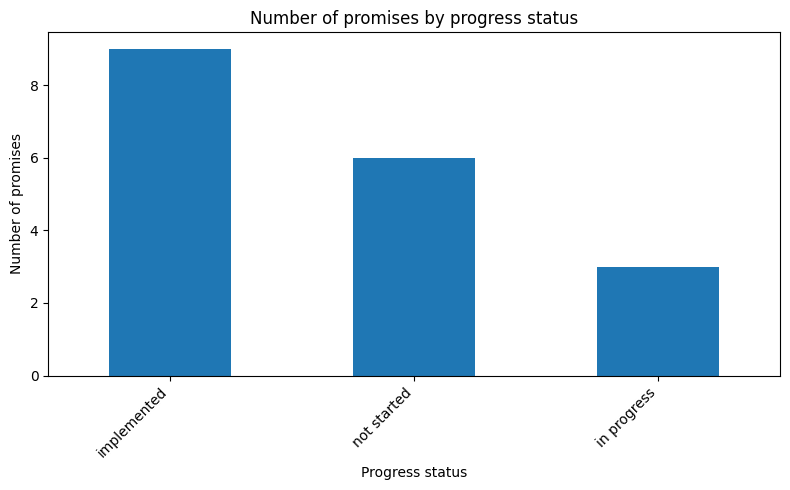

In [11]:
# Status distribution
if not main_promises.empty:
    status_col = find_column(main_promises, ["status", "progress_status", "current_status"])

    if status_col:
        status_counts = (
            main_promises[status_col]
            .fillna("Unknown")
            .value_counts()
            .rename_axis("status")
            .reset_index(name="count")
        )
        display(status_counts)

        ax = status_counts.plot(
            x="status",
            y="count",
            kind="bar",
            legend=False,
            figsize=(8, 5)
        )
        ax.set_title("Number of promises by progress status")
        ax.set_xlabel("Progress status")
        ax.set_ylabel("Number of promises")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "status_distribution_bar.png", dpi=300)
        plt.show()
    else:
        print("No status column detected in the promise dataset.")
else:
    print("No promise dataset available.")

Figure 1 represents the distribution of all 18 housing promises by their current status. As shown in the bar chart, 9 out of 18 promises have been implemented within 2 years after Manifesto, which indicates the Labor initially focused on passing legislation. The other 3 promises are in progress, while 6 promises remain not started. But this does not mean that the government has achieved nothing at all. For example, the goal of delivering the largest increase in social and affordable housing in a generation requires more time or more data to support. This showcases that the Labour actively takes action of laws and policy reforms in early times, but the progress of long-term housing targets remains limited.

## T5.2 Status distribution pie chart

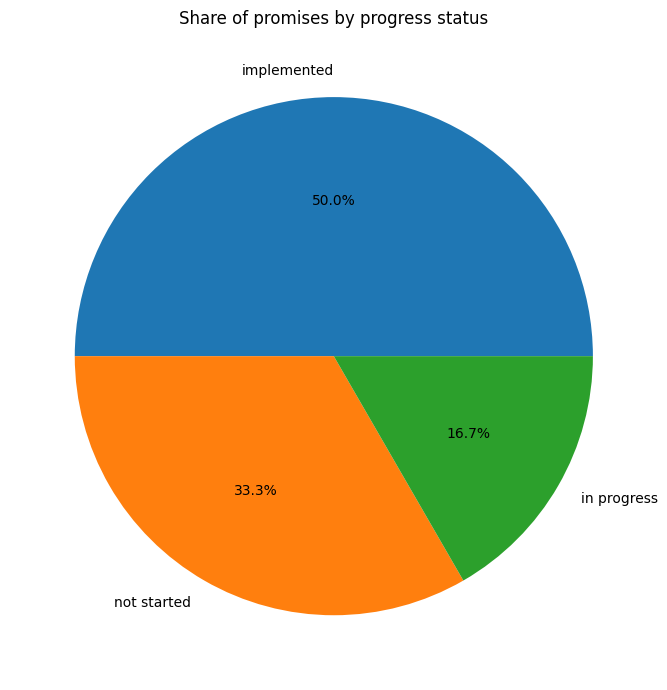

In [12]:
# Pie chart of progress status
if not main_promises.empty:
    status_col = find_column(main_promises, ["status", "progress_status", "current_status"])

    if status_col:
        status_counts = main_promises[status_col].fillna("Unknown").value_counts()

        ax = status_counts.plot(
            kind="pie",
            autopct="%1.1f%%",
            figsize=(7, 7)
        )
        ax.set_title("Share of promises by progress status")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "status_distribution_pie.png", dpi=300)
        plt.show()
    else:
        print("No status column detected in the promise dataset.")
else:
    print("No promise dataset available.")

Figure 2 reinforces the finding of Figure 1 from proportional views. 50% of promises have been fully implemented, while 16.7% are in progress. These two categories accounted for the majority, indicating that the government’s commitments are effectively processed. The remaining 33.3% of promises has not started worth tracking as they determine whether the Labour’s manifesto succeeds or not.

## T5.3 Progress score analysis

This section compares numerical progress scores if they exist.  
It can also create a score from status labels if no score column is present.


Using existing score column: progress_score


,promise_id,promise_text,topic,keywords,status,progress_score,evidence_summary,last_checked,has_parliamentary_bill,has_enacted_legislation,parliamentary_evidence_count,parliamentary_status,analysis_progress_score
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,1.5 million new homes; housebuilding; housing supply; new homes; planning reform,in progress,50,No parliamentary evidence has been found yet. This promise needs to be tracked through housing delivery statistics and government policy updates.,2026-06-10,False,False,0,No Evidence,50
1,H02,Restore mandatory local housing targets by updating the NPPF immediately after taking office.,Planning reform,mandatory housing targets; NPPF; National Planning Policy Framework; local housing targets; housebuilding targets,implemented,100,Parliamentary evidence indicates that this promise has been enacted through updates to the planning framework.,2026-06-10,False,True,1,Enacted,100
2,H03,Require all planning authorities to maintain up-to-date Local Plans; strengthen the presumption in favour of development.,Planning reform,local plans; planning authorities; presumption in favour of development; NPPF; planning policy,implemented,100,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted,100
3,H04,"Fund additional planning officers in local authorities, financed through a higher stamp duty surcharge on non-UK resident buyers.",Planning capacity,planning officers; local authorities; stamp duty surcharge; non-UK resident buyers; planning capacity,not started,0,No parliamentary evidence has been found yet. This promise needs to be tracked through budget documents and local government funding announcements.,2026-06-10,False,False,0,No Evidence,0
4,H05,Introduce a brownfield-first planning approach and fast-track approvals for urban brownfield sites.,Brownfield development,brownfield first; brownfield land; urban brownfield sites; fast-track approvals; planning reform,implemented,100,Parliamentary evidence indicates that this promise has been enacted.,2026-06-10,False,True,1,Enacted,100


Average progress score: 58.33


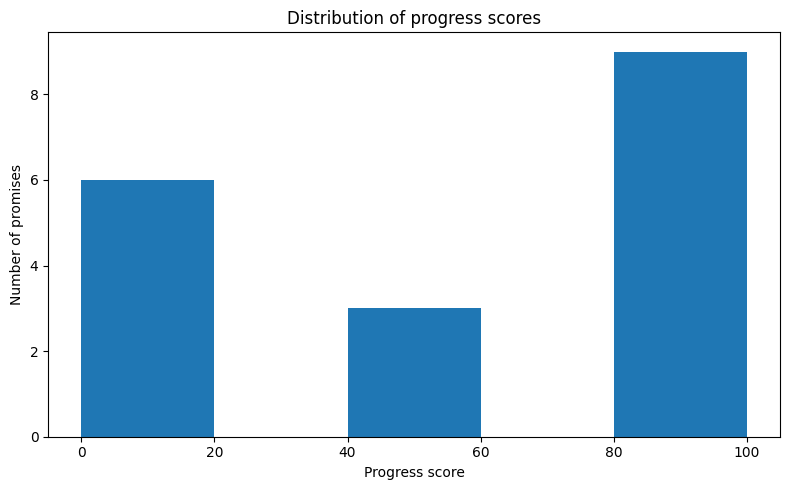

In [13]:
# Create or detect progress score
if not main_promises.empty:
    score_col = find_column(main_promises, ["progress_score", "auto_progress_score", "score"])
    status_col = find_column(main_promises, ["status", "progress_status", "current_status"])

    status_score_map = {
        "not started": 0,
        "no evidence": 0,
        "unclear": 1,
        "blocked": 1,
        "in progress": 2,
        "ongoing": 2,
        "partially fulfilled": 3,
        "partial": 3,
        "fulfilled": 4,
        "completed": 4,
        "delivered": 4
    }

    analysis_promises = main_promises.copy()

    if score_col:
        analysis_promises["analysis_progress_score"] = pd.to_numeric(analysis_promises[score_col], errors="coerce")
        print("Using existing score column:", score_col)
    elif status_col:
        analysis_promises["analysis_progress_score"] = (
            analysis_promises[status_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(status_score_map)
        )
        print("Created score from status column:", status_col)
    else:
        analysis_promises["analysis_progress_score"] = np.nan
        print("No score or status column available.")

    display(analysis_promises.head())

    if analysis_promises["analysis_progress_score"].notna().any():
        print("Average progress score:", round(analysis_promises["analysis_progress_score"].mean(), 2))

        ax = analysis_promises["analysis_progress_score"].dropna().plot(
            kind="hist",
            bins=5,
            figsize=(8, 5)
        )
        ax.set_title("Distribution of progress scores")
        ax.set_xlabel("Progress score")
        ax.set_ylabel("Number of promises")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "progress_score_distribution.png", dpi=300)
        plt.show()
else:
    print("No promise dataset available.")

## T5.4 Progress by policy area

status,implemented,in progress,not started
topic,,,
Brownfield development,1,0,0
Building safety,0,0,1
Devolution and housing powers,1,0,0
First-time buyers,0,0,1
Green Belt reform,0,1,0
Homelessness,0,1,0
Housing supply,0,1,0
Land and compulsory purchase,1,0,0
Leasehold and estate charges,1,0,0


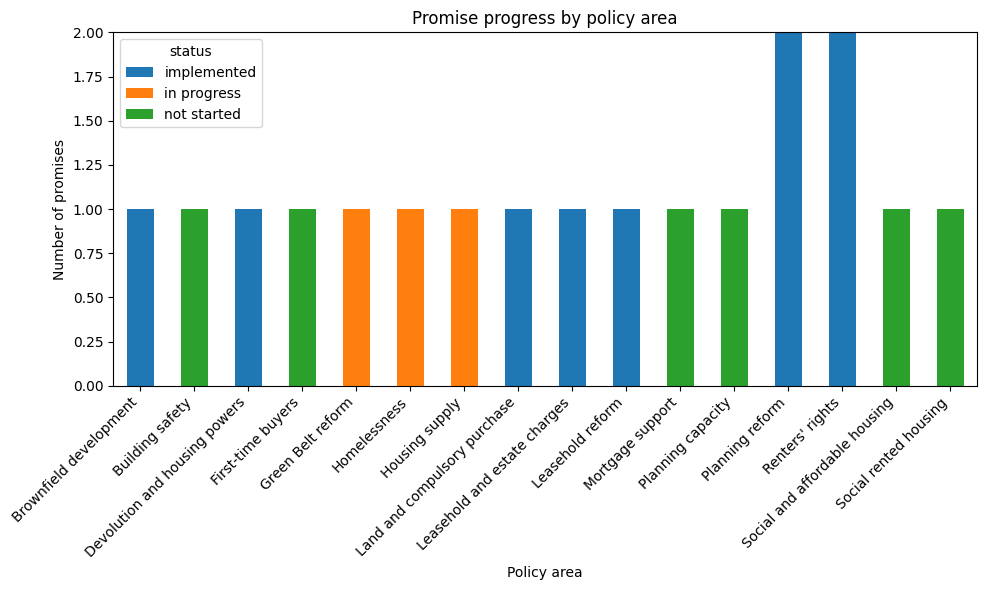

In [14]:
# Progress by policy area
if not main_promises.empty:
    status_col = find_column(main_promises, ["status", "progress_status", "current_status"])
    area_col = find_column(main_promises, ["policy_area", "area", "category", "topic"])

    if status_col and area_col:
        area_status = pd.crosstab(
            main_promises[area_col].fillna("Unknown"),
            main_promises[status_col].fillna("Unknown")
        )
        display(area_status)

        ax = area_status.plot(kind="bar", stacked=True, figsize=(10, 6))
        ax.set_title("Promise progress by policy area")
        ax.set_xlabel("Policy area")
        ax.set_ylabel("Number of promises")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "progress_by_policy_area.png", dpi=300)
        plt.show()
    else:
        print("Need both a policy area column and a status column.")
        print("Detected area column:", area_col)
        print("Detected status column:", status_col)
else:
    print("No promise dataset available.")

Figure 4 showcases the implementation of the Labour policies across different housing topics. Renters’ right and planning reform show the highest rate of implementation as largely they were delivered through specific legislative resolution. In contrast, topics like devolution, social rented housing and first-time buyers has installed, as depending on long-term construction and tracking which takes time to materialize. Such differences also illustrate the distinction between legislative capacity and real-world outcomes.

## T5.5 Evidence coverage per promise

,promise_id,evidence_count
0,H13,17
1,H07,15
2,H14,14
3,H08,7
4,H03,7
5,H02,6
6,H16,6
7,H01,6
8,H05,5
9,H06,4


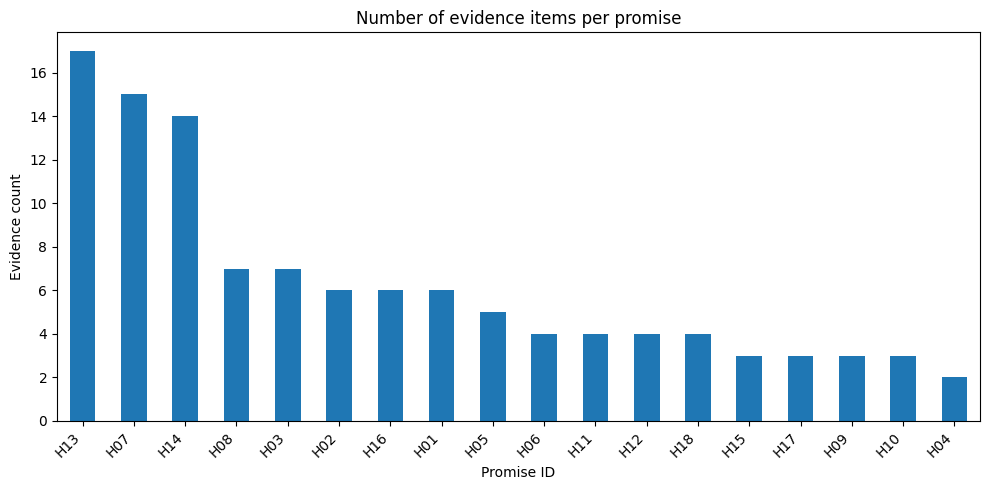

In [15]:
# Evidence count per promise
if not evidence_df_for_analysis.empty:
    promise_id_evidence_col = find_column(evidence_df_for_analysis, ["promise_id", "id"])

    if promise_id_evidence_col:
        evidence_counts = (
            evidence_df_for_analysis[promise_id_evidence_col]
            .fillna("Unknown")
            .value_counts()
            .rename_axis("promise_id")
            .reset_index(name="evidence_count")
        )
        display(evidence_counts)

        ax = evidence_counts.plot(
            x="promise_id",
            y="evidence_count",
            kind="bar",
            legend=False,
            figsize=(10, 5)
        )
        ax.set_title("Number of evidence items per promise")
        ax.set_xlabel("Promise ID")
        ax.set_ylabel("Evidence count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "evidence_count_per_promise.png", dpi=300)
        plt.show()
    else:
        print("No promise_id column detected in evidence dataset.")
else:
    print("No evidence dataset available.")

Figure 5 demonstrates the number of evidence coverage for each promise. H13(law commission leasehold reforms) has the highest evidences of 17 items, followed by H07 (the largest increase in social and affordable housing in a generation) with 15 evidences and H14 (capping  unaffordable ground rents) pf 14 evidences. Promises above can better be classified their status with more supporting evidence. Conversely, promises with fewer evidence require manual intervention, which reveals the limitation of our tracker.

## T5.6 Evidence timeline plot

This timeline uses `progress_timeline.csv` or `promise_progress_timeline.csv` if available.  
If these files do not contain a date column, it tries to use the evidence dataset.


,month,count
0,2024-07-01,18
1,2024-12-01,18
2,2025-06-01,18
3,2026-06-01,18


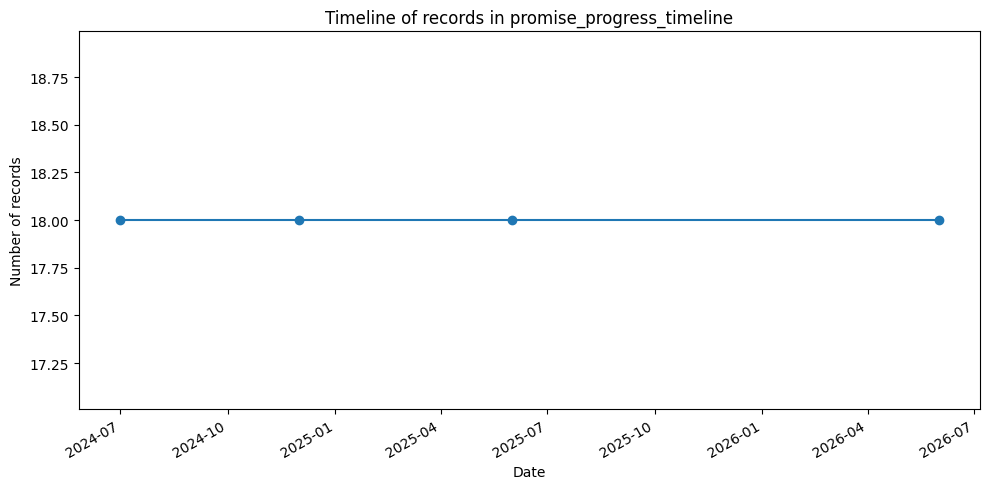

In [16]:
def make_timeline_plot(df, dataset_name):
    """
    Try to create a timeline plot from a dataframe.
    It detects a date column and then counts records by month.
    """
    if df.empty:
        print(f"{dataset_name} is empty.")
        return False

    date_col = find_column(df, [
        "date", "evidence_date", "publication_date", "published_date",
        "event_date", "updated_at", "month", "time"
    ])

    if not date_col:
        print(f"No date column detected in {dataset_name}. Columns are:")
        print(list(df.columns))
        return False

    timeline_df = df.copy()
    timeline_df[date_col] = pd.to_datetime(timeline_df[date_col], errors="coerce")
    timeline_df = timeline_df.dropna(subset=[date_col])

    if timeline_df.empty:
        print(f"No valid dates found in {dataset_name}.{date_col}")
        return False

    monthly_counts = timeline_df.groupby(timeline_df[date_col].dt.to_period("M")).size()
    monthly_counts.index = monthly_counts.index.to_timestamp()

    display(monthly_counts.rename("count").reset_index().rename(columns={date_col: "month"}))

    ax = monthly_counts.plot(kind="line", marker="o", figsize=(10, 5))
    ax.set_title(f"Timeline of records in {dataset_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of records")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{dataset_name}_timeline.png", dpi=300)
    plt.show()
    return True


timeline_created = False

for df, name in [
    (promise_progress_timeline, "promise_progress_timeline"),
    (progress_timeline, "progress_timeline"),
    (evidence_df_for_analysis, "evidence")
]:
    if make_timeline_plot(df, name):
        timeline_created = True
        break

if not timeline_created:
    print("No timeline could be created. Please check whether your timeline/evidence files have a date column.")

Figure 6 presents a timeline view of the evidence timeline plot through timeline and promise_progress_timeline dataset from July 2024 to July2026. The line remains flat at 18 promises throughout the tracking period, confirming the Labour has focused on 18 original promises and do not withdrawn or revise any commitments from the manifesto. 

## T5.7 Promise progress timeline

This section is for promise-level progress over time.  
It works best if `promise_progress_timeline.csv` contains a promise ID, a date, and a status or score.


Detected date_col: date
Detected promise_col: promise_id
Detected score_col: progress_score
Detected status_col: current_status


,promise_id,promise_text,topic,current_status,date,stage,stage_order,progress_score,note,plot_score
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,in progress,2024-07-04,Manifesto baseline,1,0.0,Promise identified from the 2024 Labour manifesto. No post-election implementation evidence had been collected yet.,0.0
1,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,in progress,2024-12-12,Initial tracking,2,12.5,"Early official policy signals or parliamentary records were checked, but the promise still required stronger evidence.",12.5
2,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,in progress,2025-06-10,Structured evidence review,3,30.0,"The promise was reviewed using structured parliamentary, governmental, budgetary, statistical, or legal evidence.",30.0
3,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,in progress,2026-06-10,Reviewed tracker assessment,4,50.0,The final score shown here follows the human-reviewed progress score in the promise dataset. Automatic suggestions are treated only as supporting ...,50.0
4,H02,Restore mandatory local housing targets by updating the NPPF immediately after taking office.,Planning reform,implemented,2024-07-04,Manifesto baseline,1,0.0,Promise identified from the 2024 Labour manifesto. No post-election implementation evidence had been collected yet.,0.0


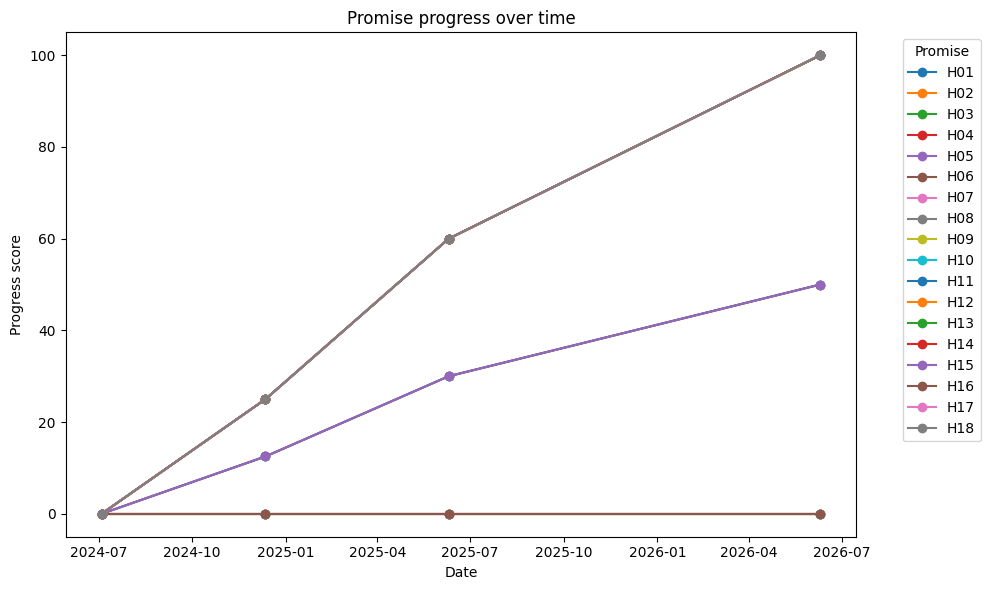

In [17]:
# Promise-level timeline if the needed columns exist
if not promise_progress_timeline.empty:
    ppt = promise_progress_timeline.copy()

    date_col = find_column(ppt, ["date", "evidence_date", "publication_date", "updated_at", "month"])
    promise_col = find_column(ppt, ["promise_id", "id", "promise"])
    score_col = find_column(ppt, ["progress_score", "auto_progress_score", "score"])
    status_col = find_column(ppt, ["status", "progress_status", "current_status"])

    print("Detected date_col:", date_col)
    print("Detected promise_col:", promise_col)
    print("Detected score_col:", score_col)
    print("Detected status_col:", status_col)

    if date_col and promise_col and (score_col or status_col):
        ppt[date_col] = pd.to_datetime(ppt[date_col], errors="coerce")
        ppt = ppt.dropna(subset=[date_col])

        if score_col:
            ppt["plot_score"] = pd.to_numeric(ppt[score_col], errors="coerce")
        else:
            status_score_map = {
                "not started": 0,
                "no evidence": 0,
                "unclear": 1,
                "blocked": 1,
                "in progress": 2,
                "ongoing": 2,
                "partially fulfilled": 3,
                "partial": 3,
                "fulfilled": 4,
                "completed": 4,
                "delivered": 4
            }
            ppt["plot_score"] = ppt[status_col].astype(str).str.strip().str.lower().map(status_score_map)

        display(ppt.head())

        ax = plt.figure(figsize=(10, 6)).gca()
        for promise_id, group in ppt.groupby(promise_col):
            group = group.sort_values(date_col)
            if group["plot_score"].notna().any():
                ax.plot(group[date_col], group["plot_score"], marker="o", label=str(promise_id))

        ax.set_title("Promise progress over time")
        ax.set_xlabel("Date")
        ax.set_ylabel("Progress score")
        ax.legend(title="Promise", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "promise_progress_over_time.png", dpi=300)
        plt.show()
    else:
        print("The file exists, but it does not have enough columns for a promise-level timeline.")
else:
    print("promise_progress_timeline.csv not loaded.")

Figure 7 tracks the promise progress over time. Most promises show a gradual upward trend as demonstrated from the chart while some are flat or even minimal progress from the beginning, such as first-time buyers and . It is also possible for some long-term promises such as first time buyers and the largest increase in social and affordable housing,which is consistent with our findings as they require longer tracking to supervise.

# T6 — Website dashboard, user guide, discussion, and limitations



This section documents the website dashboard and explains how users should understand it.

Main website files:
- `promise-tracker-website/website`
- `promise-tracker-website/promises.csv`
- `promise-tracker-website/evidence.csv`
- `promise-tracker-website/progress_timeline.csv`
- `promise-tracker-website/promise_progress_timeline.csv`
- `promise-tracker-website/promise_status_suggestions.csv`

The website is part of the project output, but the notebook should explain how the dashboard data connects to the analysis.


In [18]:
# Website data overview
website_files_summary = pd.DataFrame([
    {"file": "promises.csv", "loaded": not website_promises.empty, "rows": len(website_promises), "columns": len(website_promises.columns)},
    {"file": "evidence.csv", "loaded": not website_evidence.empty, "rows": len(website_evidence), "columns": len(website_evidence.columns)},
    {"file": "evidence_reviewed.csv", "loaded": not evidence_reviewed.empty, "rows": len(evidence_reviewed), "columns": len(evidence_reviewed.columns)},
    {"file": "progress_timeline.csv", "loaded": not progress_timeline.empty, "rows": len(progress_timeline), "columns": len(progress_timeline.columns)},
    {"file": "promise_progress_timeline.csv", "loaded": not promise_progress_timeline.empty, "rows": len(promise_progress_timeline), "columns": len(promise_progress_timeline.columns)},
    {"file": "promise_status_suggestions.csv", "loaded": not promise_status_suggestions.empty, "rows": len(promise_status_suggestions), "columns": len(promise_status_suggestions.columns)}
])

display(website_files_summary)

,file,loaded,rows,columns
0,promises.csv,True,18,12
1,evidence.csv,True,146,14
2,evidence_reviewed.csv,True,113,18
3,progress_timeline.csv,True,4,9
4,promise_progress_timeline.csv,True,72,9
5,promise_status_suggestions.csv,True,18,9


## T6 website user guide

- Explain what users can see on the dashboard.
- Explain how promise cards work.
- Explain how the timeline should be read.
- Explain what progress score and auto-progress score mean.
- Explain that the dashboard is a prototype and not a final political judgement.
- Explain which parts are manually reviewed and which parts are automatic.


## T6 discussion and limitations


- Some promises are too broad or too recent to evaluate fully.
- Official sources may not show the full political process.
- Automatic evidence collection can miss relevant sources.
- Keyword matching can collect irrelevant evidence.
- Manual review improves reliability but introduces human judgement.
- A progress score simplifies complex policy processes.
- The website is useful for transparency, but it should be read with the notes and evidence.


In [19]:
# Optional: read validation/reflection notes if available
reflection_path = NOTES_DIR / "task6_validation_reflection.md"

if reflection_path.exists():
    print(reflection_path.read_text(encoding="utf-8")[:3000])
else:
    print("task6_validation_reflection.md not found. Shenru can write the discussion and limitations here.")

# Task 6: Validation, Dashboard, and Reflection

## 1. Status Coding Scheme
| Status | Meaning | Evidence required |
|---|---|---|
| Delivered legally | The promise has clear parliamentary or legal implementation. | Act of Parliament enacted or legal reform completed. |
| Partially delivered / in progress | Some legal or policy action exists, but the full promise is not complete. | Act enacted for part of the promise, or a related bill is still in progress. |
| In progress | Government action has started, but delivery is not complete. | Policy document, bill, funding report, or official statistics. |
| Policy/funding evidence found | The promise can be traced through policy or budget documents, but not through legislation. | Government policy document, funding report, or programme document. |
| No clear evidence yet | No reliable follow-up evidence was found in the current dataset. | No linked Act, bill, policy document, funding source, or outcome indicator. |
| Too early to judge outc

# 7. Combined final analysis table

This section tries to create a combined table linking promises and evidence.  
It is flexible because the exact column names may differ across files.


In [20]:
# Build a combined table when promise_id exists in both promise and evidence data
combined_table = pd.DataFrame()

if not main_promises.empty and not evidence_df_for_analysis.empty:
    promise_id_col = find_column(main_promises, ["promise_id", "id"])
    evidence_promise_id_col = find_column(evidence_df_for_analysis, ["promise_id", "id"])

    if promise_id_col and evidence_promise_id_col:
        combined_table = main_promises.merge(
            evidence_df_for_analysis,
            left_on=promise_id_col,
            right_on=evidence_promise_id_col,
            how="left",
            suffixes=("_promise", "_evidence")
        )
        preview_df(combined_table, "combined_table", rows=10)

        output_path = DATA_PROCESSED / "combined_notebook_analysis_table.csv"
        try:
            output_path.parent.mkdir(parents=True, exist_ok=True)
            combined_table.to_csv(output_path, index=False)
            print("Saved combined table to:", output_path)
        except Exception as e:
            print("Could not save combined table:", e)
    else:
        print("Could not merge because promise_id columns were not detected.")
        print("Promise ID column:", promise_id_col)
        print("Evidence promise ID column:", evidence_promise_id_col)
else:
    print("Need both promise data and evidence data to create a combined table.")


combined_table
--------------
Shape: (113, 29)
Columns: ['promise_id', 'promise_text', 'topic', 'keywords', 'status', 'progress_score', 'evidence_summary', 'last_checked', 'has_parliamentary_bill', 'has_enacted_legislation', 'parliamentary_evidence_count', 'parliamentary_status', 'title', 'url', 'source_type', 'date_published', 'evidence_text', 'suggested_status', 'collected_at', 'evidence_id', 'relevance_score', 'checked_by_human', 'search_query', 'is_relevant', 'review_note', 'manual_description', 'normalized_url', 'global_source_key', 'is_duplicate_global_source']


,promise_id,promise_text,topic,keywords,status,progress_score,evidence_summary,last_checked,has_parliamentary_bill,has_enacted_legislation,parliamentary_evidence_count,parliamentary_status,title,url,source_type,date_published,evidence_text,suggested_status,collected_at,evidence_id,relevance_score,checked_by_human,search_query,is_relevant,review_note,manual_description,normalized_url,global_source_key,is_duplicate_global_source
0,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,1.5 million new homes; housebuilding; housing supply; new homes; planning reform,in progress,50,No parliamentary evidence has been found yet. This promise needs to be tracked through housing delivery statistics and government policy updates.,2026-06-10,False,False,0,No Evidence,Net additional dwellings,https://www.gov.uk/government/statistics/housing-supply-net-additional-dwellings-england-2024-to-2025/housing-supply-net-additional-dwellings-engl...,Statistics,2024-2025,Annual housing supply in England amounted to 208600 net additional dwellings in 2024-25.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://www.gov.uk/government/statistics/housing-supply-net-additional-dwellings-england-2024-to-2025/housing-supply-net-additional-dwellings-engl...,https://www.gov.uk/government/statistics/housing-supply-net-additional-dwellings-england-2024-to-2025/housing-supply-net-additional-dwellings-engl...,False
1,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,1.5 million new homes; housebuilding; housing supply; new homes; planning reform,in progress,50,No parliamentary evidence has been found yet. This promise needs to be tracked through housing delivery statistics and government policy updates.,2026-06-10,False,False,0,No Evidence,Housebuilding starts and completions,https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/ukhousebuildingpermanentdwellingsstartedandcompleted,Statistics,Quarterly dataset,ONS dataset bringing together quarterly UK totals for newly built dwellings started and completed.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/ukhousebuildingpermanentdwellingsstartedandcompleted,https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/ukhousebuildingpermanentdwellingsstartedandcompleted,False
2,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,1.5 million new homes; housebuilding; housing supply; new homes; planning reform,in progress,50,No parliamentary evidence has been found yet. This promise needs to be tracked through housing delivery statistics and government policy updates.,2026-06-10,False,False,0,No Evidence,Planning reform and housing target,https://www.gov.uk/government/news/planning-overhaul-to-reach-15-million-new-homes,Government policy,2024,Government announcement on planning reform connected to the target of delivering 1.5 million homes.,in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown source type, needs human review.",NaN,https://www.gov.uk/government/news/planning-overhaul-to-reach-15-million-new-homes,https://www.gov.uk/government/news/planning-overhaul-to-reach-15-million-new-homes,False
3,H01,Build 1.5 million new homes within the 2024-2029 parliament.,Housing supply,1.5 million new homes; housebuilding; housing supply; new homes; planning reform,in progress,50,No parliamentary evidence has been found yet. This promise needs to be tracked through housing delivery statistics and government policy updates.,2026-06-10,False,False,0,No Evidence,House building starts and completions,https://www.gov.uk/government/statistical-data-sets/live-tables-on-house-building,Statistics,Quarterly and annual tables,"Government live tables on house building, including permanent dwellings started and completed.",in progress,2026-06-10,NaN,40,NaN,NaN,maybe,"Unknown so

Saved combined table to: C:\Users\darko\data-driven\uk-labour-promise-tracker\data\processed\combined_notebook_analysis_table.csv


# 8. Main findings

TODO after running the analysis:

Write 3–5 main findings based on the tables and charts.



# 9. Critical reflection

This section is important because the assignment asks for critical reflection on results.

TODO:
- What can our tracker show?
- What can it not show?
- Which sources are missing?
- Which promises are difficult to track?
- Are the categories too simple?
- How reliable is the automatic pipeline?
- What would we improve in a future version?


# 10. Conclusion






# Appendix A — CRediT team contribution

This appendix is required by the assignment but non-graded.

| Team member | Project task | Contribution | CRediT roles |
|---|---|---|---|
| Selin | T1 | Project overview, research question, final integration | Conceptualization; Project Administration; Writing – Review & Editing |
| Simone | T2 | Background, related work, references | Investigation; Writing – Original Draft; Writing – Review & Editing |
| Grace | T3 | Promise dataset and manual review logic | Data Curation; Methodology; Validation |
| Alessia | T4 | Automatic evidence collection and update pipeline | Software; Data Curation; Methodology |
| Tia | T5 | Analysis, results, and visualisations | Formal Analysis; Visualization; Software |
| Shenru | T6 | Website dashboard, user guide, discussion, and limitations | Software; Visualization; Writing – Original Draft; Validation |


# Appendix B — Statement on the use of GenAI


TODO:
- Add which tools were used, for example ChatGPT, Claude, Codex, or others.
- Add which parts were supported by GenAI.
- Add how the group checked the output.


# Appendix C — References and code sources

TODO:
- Add references in Chicago style.
- Include all data sources used in the dataset.
- Include libraries or code sources if you reused external code.

Possible source groups:
- UK Labour 2024 manifesto
- UK Parliament records
- GOV.UK policy pages
- HM Treasury budget documents
- ONS housing statistics
- pandas documentation
- matplotlib documentation


# 11. Save notebook outputs

This final code cell saves key outputs created by the notebook.


In [21]:
# Save useful outputs if they exist

try:
    if "analysis_promises" in globals() and not analysis_promises.empty:
        output = DATA_PROCESSED / "notebook_promise_analysis_with_scores.csv"
        output.parent.mkdir(parents=True, exist_ok=True)
        analysis_promises.to_csv(output, index=False)
        print("Saved:", output)
except Exception as e:
    print("Could not save analysis_promises:", e)

try:
    if "status_counts" in globals():
        output = DATA_PROCESSED / "notebook_status_counts.csv"
        output.parent.mkdir(parents=True, exist_ok=True)
        status_counts.to_csv(output, index=False)
        print("Saved:", output)
except Exception as e:
    print("Could not save status_counts:", e)

try:
    if "combined_table" in globals() and not combined_table.empty:
        output = DATA_PROCESSED / "combined_notebook_analysis_table.csv"
        output.parent.mkdir(parents=True, exist_ok=True)
        combined_table.to_csv(output, index=False)
        print("Saved:", output)
except Exception as e:
    print("Could not save combined_table:", e)

print("Notebook output saving step finished.")

Saved: C:\Users\darko\data-driven\uk-labour-promise-tracker\data\processed\notebook_promise_analysis_with_scores.csv
Saved: C:\Users\darko\data-driven\uk-labour-promise-tracker\data\processed\notebook_status_counts.csv
Saved: C:\Users\darko\data-driven\uk-labour-promise-tracker\data\processed\combined_notebook_analysis_table.csv
Notebook output saving step finished.
